

# Customer Churn Prediction Using Machine Learning



## 📌 Project Overview

This project predicts whether a telecom customer is likely to churn using machine learning techniques.

The project includes data cleaning, exploratory data analysis, feature engineering, model training, model evaluation, and business insights.

### 🛠️ Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
* Google Colab

### 🤖 Machine Learning Models

* Logistic Regression
* Random Forest Classifier

### 🎯 Final Model

Logistic Regression

### 📊 Model Performance

* Accuracy: 80.88%
* Churn Recall: 0.54
* Churn F1-Score: 0.60

### 💼 Business Objective

The model can help identify customers who may be at higher risk of churn so that businesses can analyze those customers and consider appropriate retention strategies.


In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [92]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset imported successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset imported successfully!
Rows: 7043
Columns: 21


In [93]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [94]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null

In [95]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Series([], dtype: int64)


In [96]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [97]:
print("Churn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [98]:
# Convert TotalCharges from object to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values created after conversion
print("Missing values in TotalCharges:", df["TotalCharges"].isnull().sum())

Missing values in TotalCharges: 11


In [99]:
# Remove rows with missing TotalCharges
df = df.dropna(subset=["TotalCharges"])

print("Dataset shape after cleaning:", df.shape)
print("Missing values after cleaning:", df.isnull().sum().sum())

Dataset shape after cleaning: (7032, 21)
Missing values after cleaning: 0


In [100]:
# Remove customerID because it is only an identifier
df = df.drop("customerID", axis=1)

print("Columns after removing customerID:")
print(df.columns.tolist())

Columns after removing customerID:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [101]:
print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Final Dataset Shape: (7032, 20)

Missing Values:
0

Duplicate Rows:
22


In [102]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)
print("Duplicate rows remaining:", df.duplicated().sum())

Dataset shape after removing duplicates: (7010, 20)
Duplicate rows remaining: 0


In [103]:
print("Final Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (7010, 20)
Missing Values: 0
Duplicate Rows: 0


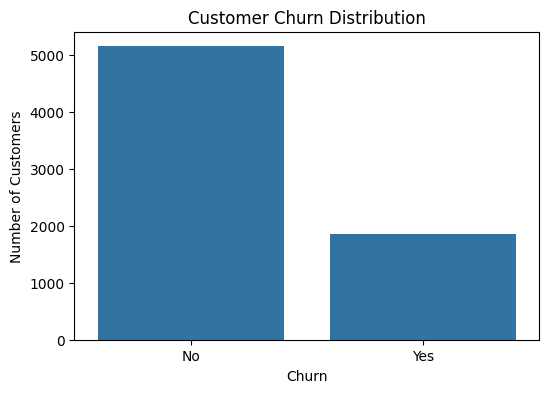

In [104]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [105]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.509272
Yes    26.490728
Name: proportion, dtype: float64


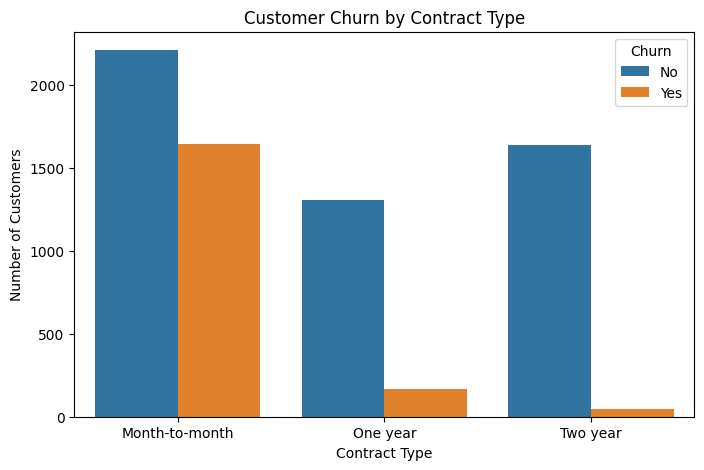

In [106]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

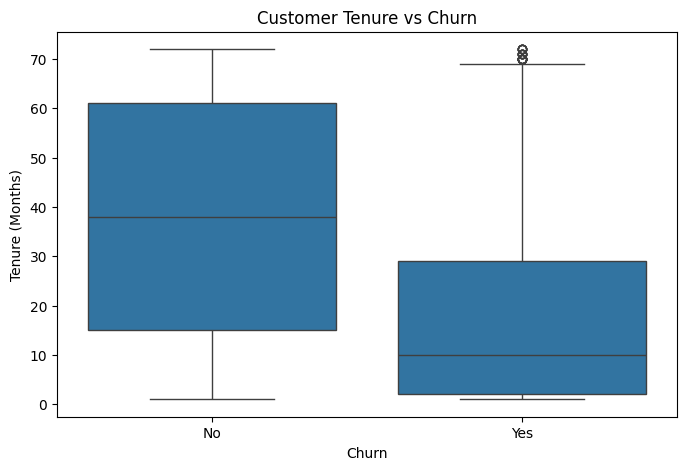

In [107]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [108]:
# Convert target variable Churn into numerical values
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print(df["Churn"].value_counts())

Churn
0    5153
1    1857
Name: count, dtype: int64


In [109]:
# Display categorical columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

Categorical Columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [110]:
# Display numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [111]:
# Convert categorical variables into numerical variables
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("Encoded Dataset Shape:", df_encoded.shape)

Encoded Dataset Shape: (7010, 31)


In [112]:
# Convert boolean columns to integers
bool_columns = df_encoded.select_dtypes(include=["bool"]).columns

df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

print(df_encoded.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0            0   
1              0      34           56.95       1889.50      0            1   
2              0       2           53.85        108.15      1            1   
3              0      45           42.30       1840.75      0            1   
4              0       2           70.70        151.65      1            0   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0            1               0                 0   
1            0               0                 1   
2            0               0                 1   
3            0               0                 0   
4            0               0                 1   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                               1  ...                                0   
1                               0  ...                              

In [113]:
print("Final ML Dataset Shape:", df_encoded.shape)

print("\nData Types:")
print(df_encoded.dtypes.value_counts())

print("\nMissing Values:")
print(df_encoded.isnull().sum().sum())

Final ML Dataset Shape: (7010, 31)

Data Types:
int64      29
float64     2
Name: count, dtype: int64

Missing Values:
0


In [114]:
# Separate features and target
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7010, 30)
Target shape: (7010,)


In [115]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5608, 30)
Testing data: (1402, 30)


In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


In [117]:
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [118]:
# Make predictions on test data
y_pred = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0]


In [119]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 80.88%


In [120]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.87      1031
           1       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402



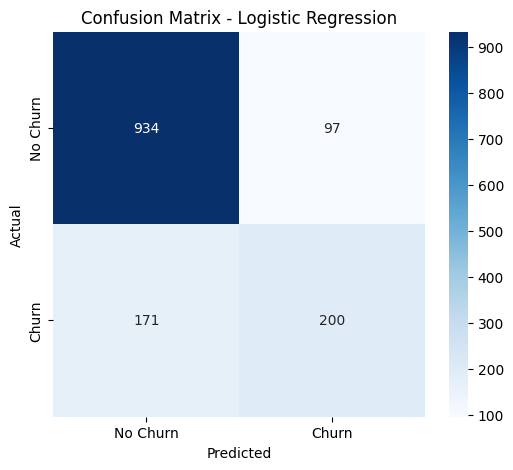

In [121]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [122]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [123]:
# Make predictions
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions generated successfully!")

Random Forest predictions generated successfully!


In [124]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

Random Forest Accuracy: 78.89%


In [125]:
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1031
           1       0.63      0.49      0.55       371

    accuracy                           0.79      1402
   macro avg       0.73      0.69      0.71      1402
weighted avg       0.78      0.79      0.78      1402



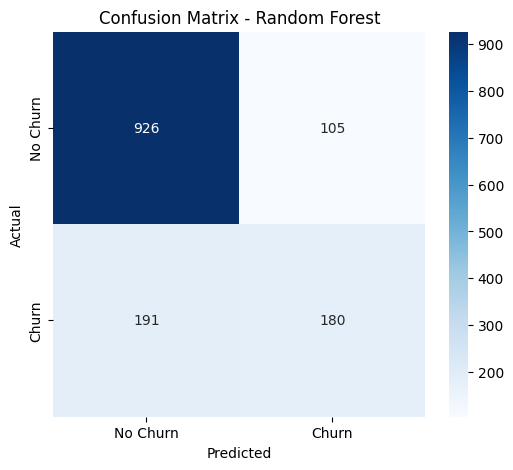

In [126]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [127]:
# Get feature importance from Logistic Regression

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

# Sort by absolute coefficient
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
                           Feature  Coefficient  Absolute_Coefficient
1                           tenure    -1.417202              1.417202
3                     TotalCharges     0.726308              0.726308
25               Contract_Two year    -0.571146              0.571146
10     InternetService_Fiber optic     0.517509              0.517509
2                   MonthlyCharges    -0.330064              0.330064
24               Contract_One year    -0.279345              0.279345
26            PaperlessBilling_Yes     0.184816              0.184816
9                MultipleLines_Yes     0.154627              0.154627
28  PaymentMethod_Electronic check     0.149189              0.149189
19                 TechSupport_Yes    -0.142096              0.142096


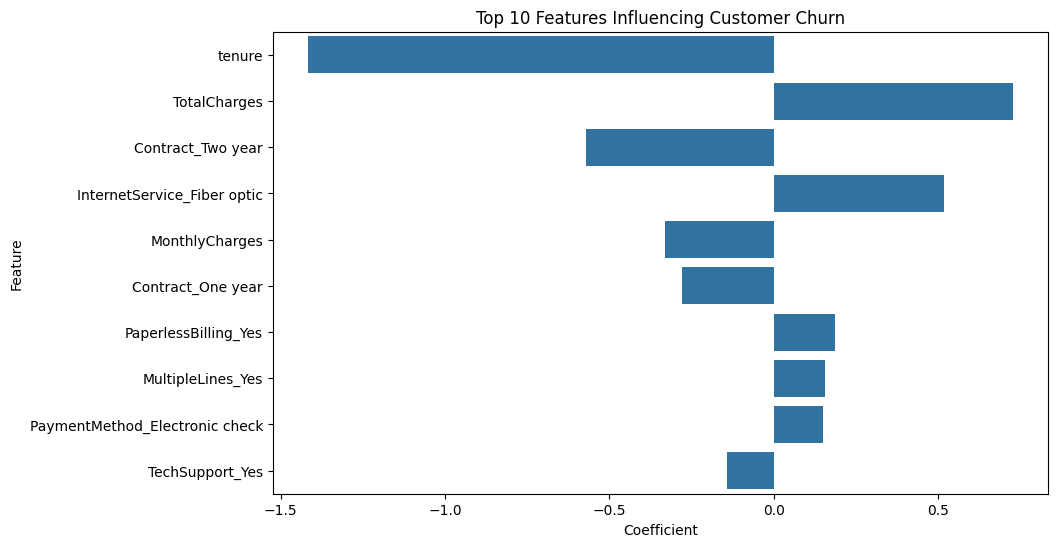

In [128]:
# Visualize Top 10 Features

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

In [129]:
print("===== BUSINESS INSIGHTS =====")

print("1. Customers with shorter tenure show a higher tendency to churn.")
print("2. Customers with longer-term contracts show lower churn tendency.")
print("3. Fiber optic internet customers show higher churn tendency in this model.")
print("4. Customers with tech support show lower churn tendency.")
print("5. Electronic check payment is associated with higher churn tendency.")
print("6. The model can help identify customers who may require retention efforts.")

===== BUSINESS INSIGHTS =====
1. Customers with shorter tenure show a higher tendency to churn.
2. Customers with longer-term contracts show lower churn tendency.
3. Fiber optic internet customers show higher churn tendency in this model.
4. Customers with tech support show lower churn tendency.
5. Electronic check payment is associated with higher churn tendency.
6. The model can help identify customers who may require retention efforts.


In [130]:
print("===== CUSTOMER CHURN PREDICTION PROJECT =====")

print("\nProject Objective:")
print("Predict whether a customer is likely to churn using machine learning.")

print("\nDataset:")
print("IBM Telco Customer Churn Dataset")

print("\nData Preparation:")
print("- Converted TotalCharges to numeric")
print("- Removed missing values")
print("- Removed duplicate records")
print("- Removed customerID")
print("- Applied one-hot encoding to categorical variables")
print("- Applied feature scaling")

print("\nModels Tested:")
print("- Logistic Regression")
print("- Random Forest")

print("\nFinal Model:")
print("Logistic Regression")

print("\nModel Performance:")
print("Accuracy: 80.88%")
print("Churn Recall: 0.54")
print("Churn F1-Score: 0.60")

print("\nKey Business Insights:")
print("- Shorter-tenure customers show higher churn tendency.")
print("- Longer-term contracts show lower churn tendency.")
print("- Fiber optic customers show higher churn tendency in this model.")
print("- Customers with tech support show lower churn tendency.")
print("- Electronic check payment is associated with higher churn tendency.")

===== CUSTOMER CHURN PREDICTION PROJECT =====

Project Objective:
Predict whether a customer is likely to churn using machine learning.

Dataset:
IBM Telco Customer Churn Dataset

Data Preparation:
- Converted TotalCharges to numeric
- Removed missing values
- Removed duplicate records
- Removed customerID
- Applied one-hot encoding to categorical variables
- Applied feature scaling

Models Tested:
- Logistic Regression
- Random Forest

Final Model:
Logistic Regression

Model Performance:
Accuracy: 80.88%
Churn Recall: 0.54
Churn F1-Score: 0.60

Key Business Insights:
- Shorter-tenure customers show higher churn tendency.
- Longer-term contracts show lower churn tendency.
- Fiber optic customers show higher churn tendency in this model.
- Customers with tech support show lower churn tendency.
- Electronic check payment is associated with higher churn tendency.


## 📋 Project Workflow

1. Import Libraries
2. Load Dataset
3. Understand the Dataset
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Train-Test Split
8. Feature Scaling
9. Logistic Regression
10. Random Forest
11. Model Comparison
12. Feature Importance
13. Business Insights
14. Final Conclusion


In [131]:
# Model Comparison

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.8088, 0.7889],
    "Churn Recall": [0.54, 0.49],
    "Churn F1-Score": [0.60, 0.55]
})

comparison["Accuracy"] = comparison["Accuracy"] * 100

print("Model Comparison:")
display(comparison)

Model Comparison:


,Model,Accuracy,Churn Recall,Churn F1-Score
0,Logistic Regression,80.88,0.54,0.60
1,Random Forest,78.89,0.49,0.55


## 📊 Model Comparison

Two machine learning models were evaluated for customer churn prediction: Logistic Regression and Random Forest.

Based on the test-set results, Logistic Regression achieved higher accuracy, churn recall, and churn F1-score than Random Forest.

Therefore, Logistic Regression was selected as the final model for this project.


## 🎯 Final Conclusion

This project successfully developed a machine learning model to predict customer churn using the IBM Telco Customer Churn dataset.

The data was cleaned and prepared using missing-value handling, duplicate removal, categorical encoding, and feature scaling. Exploratory Data Analysis was performed to understand customer churn patterns.

Two machine learning models were tested: Logistic Regression and Random Forest.

Logistic Regression achieved an accuracy of 80.88%, with a churn recall of 0.54 and a churn F1-score of 0.60 on the test set. Based on these evaluation results, Logistic Regression was selected as the final model.

The analysis also identified customer characteristics associated with churn, such as tenure, contract type, internet service, payment method, and availability of technical support.

Overall, this project demonstrates an end-to-end machine learning workflow from data preparation and analysis to model evaluation and business insights.
